# Quantum Repeater Network — Aggregate Metrics
Demonstrates `QuantumRepeaterNetwork.network_metrics()` over all source nodes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sequential_repeaters_dist import RepeaterParams, QuantumRepeaterNetwork, build_s2_graph

## 1 — Build the network

In [13]:
params = RepeaterParams()
params.p_det     = 0.95
params.alpha     = 0.18
params.q_0       = 0.01
params.nu        = 1e9
params.R_dark    = 100
params.delta_det = 100e-12
params.p_pair    = 0.05
params.eta_c     = 0.8
params.P_BSM     = 0.5
params.T_coh     = 0.05

A, dist, coords = build_s2_graph(N=1000, beta=2.6261, mu=0.0233, scale='city')

net = QuantumRepeaterNetwork(
    params, A, dist, coords,
    architecture='node',
    scale='city',
    distillation=True,
)

## 2 — Compute aggregate metrics (all sources)

In [14]:
metrics = net.network_metrics(verbose=True)

  Computing paths from source 0 / 999 …
  Computing paths from source 1 / 999 …
  Computing paths from source 2 / 999 …
  Computing paths from source 3 / 999 …
  Computing paths from source 4 / 999 …
  Computing paths from source 5 / 999 …
  Computing paths from source 6 / 999 …
  Computing paths from source 7 / 999 …
  Computing paths from source 8 / 999 …
  Computing paths from source 9 / 999 …
  Computing paths from source 10 / 999 …
  Computing paths from source 11 / 999 …
  Computing paths from source 12 / 999 …
  Computing paths from source 13 / 999 …
  Computing paths from source 14 / 999 …
  Computing paths from source 15 / 999 …
  Computing paths from source 16 / 999 …
  Computing paths from source 17 / 999 …
  Computing paths from source 18 / 999 …
  Computing paths from source 19 / 999 …
  Computing paths from source 20 / 999 …
  Computing paths from source 21 / 999 …
  Computing paths from source 22 / 999 …
  Computing paths from source 23 / 999 …
  Computing paths from sou

In [15]:
print(f"Average rate                : {metrics['avg_rate']:.4e} pairs/s")
print(f"Avg distance-weighted rate  : {metrics['avg_dist_weighted_rate']:.4e} pairs·km/s")
print(f"Reachability                : {metrics['reachability']*100:.2f} %")
print(f"Viable pairs                : {metrics['n_viable_pairs']} / {metrics['n_total_pairs']}")

Average rate                : 1.3578e+06 pairs/s
Avg distance-weighted rate  : 2.0538e+07 pairs·km/s
Reachability                : 30.82 %
Viable pairs                : 307882 / 999000


## 3 — Per-source breakdown

In [16]:
# Build a summary DataFrame from the per-source results
summary = pd.DataFrame([
    {
        'source':               r['source'],
        'avg_rate':             r['avg_rate'],
        'avg_dist_weighted_rate': r['avg_dist_weighted_rate'],
        'reachability':         r['reachability'],
    }
    for r in metrics['per_source']
]).set_index('source')

summary.head(10)

,avg_rate,avg_dist_weighted_rate,reachability
source,,,
0,1.597872e+06,1.673700e+07,0.252252
1,1.485074e+06,1.693394e+07,0.352352
2,1.247057e+06,2.038562e+07,0.412412
3,1.613032e+06,1.827560e+07,0.394394
4,1.464745e+06,1.241538e+07,0.056056
5,1.683556e+06,2.483401e+07,0.738739
6,1.255070e+06,1.738355e+07,0.313313
7,1.460688e+06,2.013964e+07,0.418418
8,1.306732e+06,1.693490e+07,0.330330


## 4 — Quick plots

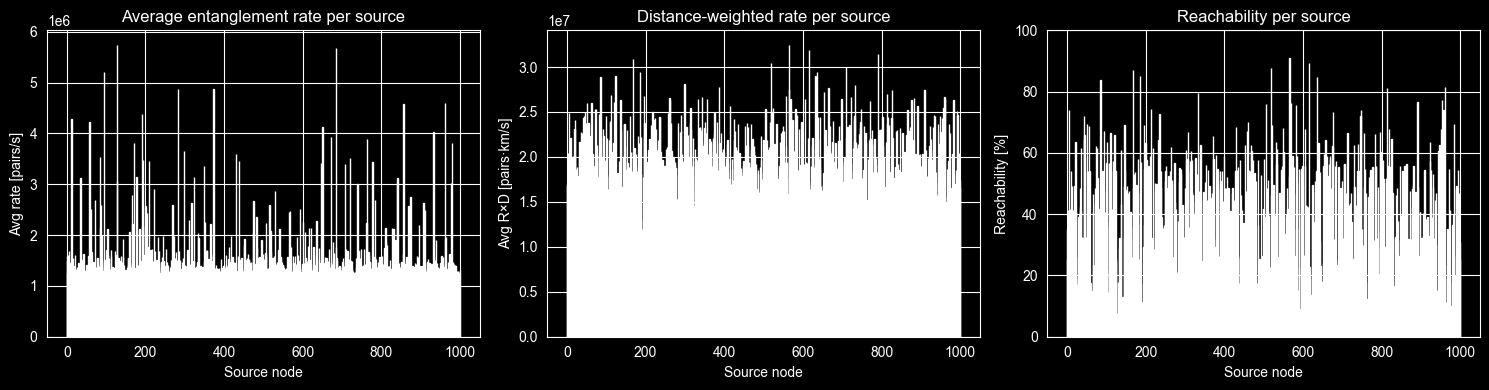

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(summary.index, summary['avg_rate'])
axes[0].set_xlabel('Source node')
axes[0].set_ylabel('Avg rate [pairs/s]')
axes[0].set_title('Average entanglement rate per source')

axes[1].bar(summary.index, summary['avg_dist_weighted_rate'], color='darkorange')
axes[1].set_xlabel('Source node')
axes[1].set_ylabel('Avg R×D [pairs·km/s]')
axes[1].set_title('Distance-weighted rate per source')

axes[2].bar(summary.index, summary['reachability'] * 100, color='steelblue')
axes[2].set_xlabel('Source node')
axes[2].set_ylabel('Reachability [%]')
axes[2].set_title('Reachability per source')
axes[2].set_ylim(0, 100)

plt.tight_layout()
plt.show()

## 5 — Optional: compute metrics for a subset of sources only

In [7]:
# Only use the first 5 nodes as sources
metrics_subset = net.network_metrics(sources=range(5), verbose=False)
print(metrics_subset['avg_rate'], metrics_subset['reachability'])

9892141.917358872 0.27346938775510204
